In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("used_cars_data_final_prices_formatted.csv")

In [ ]:
print(df.head())



   S.No.                              Name    Location  Year  \
0      0            Maruti Wagon R LXI CNG      Mumbai  2010   
1      1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015   
2      2                      Honda Jazz V     Chennai  2011   
3      3                 Maruti Ertiga VDI     Chennai  2012   
4      4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013   

   Kilometers_Driven Fuel_Type Transmission Owner_Type     Mileage   Engine  \
0              72000       CNG       Manual      First  26.6 km/kg   998 CC   
1              41000    Diesel       Manual      First  19.67 kmpl  1582 CC   
2              46000    Petrol       Manual      First   18.2 kmpl  1199 CC   
3              87000    Diesel       Manual      First  20.77 kmpl  1248 CC   
4              40670    Diesel    Automatic     Second   15.2 kmpl  1968 CC   

       Power  Seats New_Price      Price  
0  58.16 bhp    5.0       NaN   1,75,000  
1  126.2 bhp    5.0       NaN  12,50,000  
2   88.7 bh

In [14]:
df.describe()

,S.No.,Year,Kilometers_Driven,Seats
count,7253.000000,7253.000000,7.253000e+03,7200.000000
mean,3626.000000,2013.365366,5.869906e+04,5.279722
std,2093.905084,3.254421,8.442772e+04,0.811660
min,0.000000,1996.000000,1.710000e+02,0.000000
25%,1813.000000,2011.000000,3.400000e+04,5.000000
50%,3626.000000,2014.000000,5.341600e+04,5.000000
75%,5439.000000,2016.000000,7.300000e+04,5.000000
max,7252.000000,2019.000000,6.500000e+06,10.000000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7170 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   object 
dtypes: float64(1), int64(3), object(10)
memory usage: 793.4+ KB


In [16]:
df.shape

(7253, 14)

In [ ]:
df.isnull().values.any()
df.isnull().sum().sum()


np.int64(7709)

In [24]:
(df.isnull().sum()/len(df))*100

S.No.                 0.000000
Name                  0.000000
Location              0.000000
Year                  0.000000
Kilometers_Driven     0.000000
Fuel_Type             0.000000
Transmission          0.000000
Owner_Type            0.000000
Mileage               1.144354
Engine                0.634220
Power                 0.634220
Seats                 0.730732
New_Price            86.129877
Price                17.013650
dtype: float64

<Axes: >

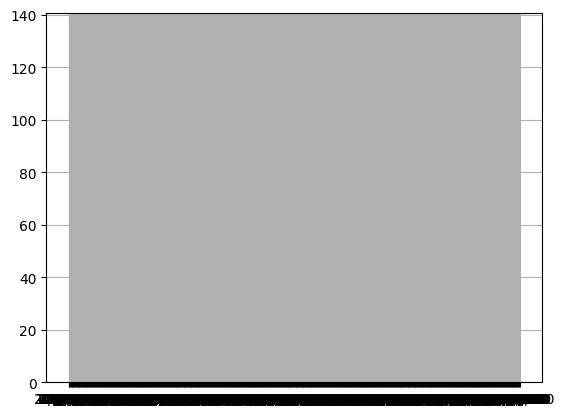

In [28]:
df['New_Price'].hist()

<Axes: >

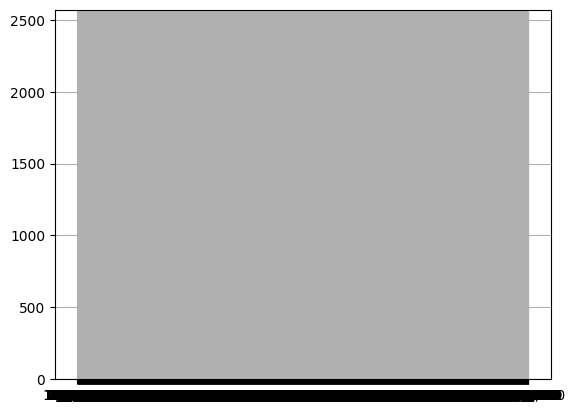

In [29]:
df['Price'].hist()

In [97]:
df = df.dropna(subset=['Price'])
df.isnull().sum()

Year                         0
Kilometers_Driven            0
Mileage                      0
Engine                       0
Power                        0
                            ..
Transmission_Manual          0
Owner_Type_First             0
Owner_Type_Fourth & Above    0
Owner_Type_Second            0
Owner_Type_Third             0
Length: 1844, dtype: int64

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5876 entries, 0 to 6018
Columns: 1844 entries, Year to Owner_Type_Third
dtypes: bool(1836), float64(5), int64(3)
memory usage: 10.8 MB


In [77]:
df['New_Price'] = pd.to_numeric(df['New_Price'], errors='coerce')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Engine'] = pd.to_numeric(df['Engine'],errors='coerce')
df['Power']=pd.to_numeric(df['Power'],errors='coerce')

In [78]:
df['Engine'] = df['Engine'].fillna(df['Engine'].mean())
df['New_Price'] = df['New_Price'].fillna(df['New_Price'].median())
df['Seats'] = df['Seats'].fillna(df['Seats'].mean())
df['Mileage'] = df['Mileage'].fillna(df['Mileage'].mean())
df['Power']=df['Power'].fillna(df['Power'].mean())

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5876 entries, 0 to 6018
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              5876 non-null   int64  
 1   Name               5876 non-null   object 
 2   Location           5876 non-null   object 
 3   Year               5876 non-null   int64  
 4   Kilometers_Driven  5876 non-null   int64  
 5   Fuel_Type          5876 non-null   object 
 6   Transmission       5876 non-null   object 
 7   Owner_Type         5876 non-null   object 
 8   Mileage            5876 non-null   float64
 9   Engine             5876 non-null   float64
 10  Power              5876 non-null   float64
 11  Seats              5876 non-null   float64
 12  New_Price          5876 non-null   float64
 13  Price              5876 non-null   object 
 14  power              5876 non-null   float64
dtypes: float64(6), int64(3), object(6)
memory usage: 734.5+ KB


In [85]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5876 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              5876 non-null   int64  
 1   Name               5876 non-null   object 
 2   Location           5876 non-null   object 
 3   Year               5876 non-null   int64  
 4   Kilometers_Driven  5876 non-null   int64  
 5   Fuel_Type          5876 non-null   object 
 6   Transmission       5876 non-null   object 
 7   Owner_Type         5876 non-null   object 
 8   Mileage            5876 non-null   float64
 9   Engine             5876 non-null   float64
 10  Power              5876 non-null   float64
 11  Seats              5876 non-null   float64
 12  New_Price          5876 non-null   float64
 13  Price              5876 non-null   object 
dtypes: float64(5), int64(3), object(6)
memory usage: 688.6+ KB


In [92]:

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


In [93]:
df = pd.get_dummies(df, columns=['Fuel_Type','Name','Location','Transmission','Owner_Type'])

In [95]:
df.dtypes

Year                           int64
Kilometers_Driven              int64
Mileage                      float64
Engine                       float64
Power                        float64
                              ...   
Transmission_Manual             bool
Owner_Type_First                bool
Owner_Type_Fourth & Above       bool
Owner_Type_Second               bool
Owner_Type_Third                bool
Length: 1844, dtype: object

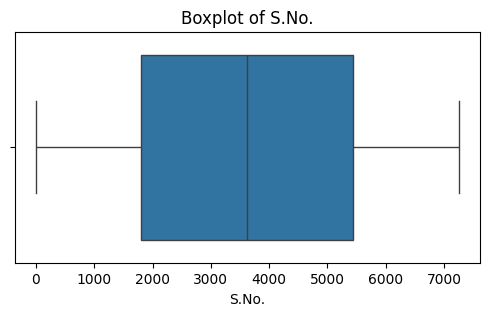

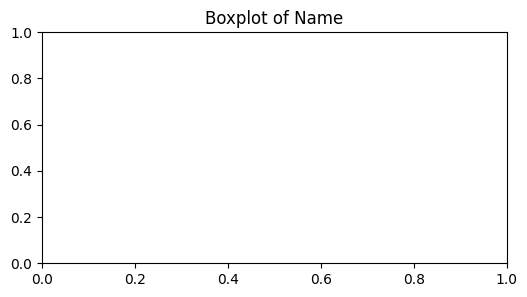

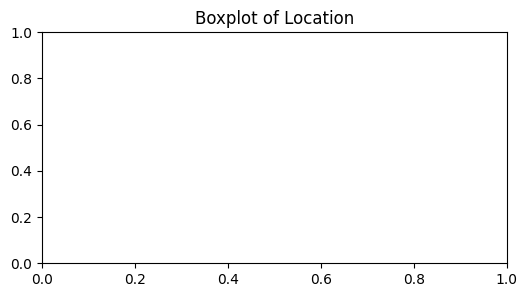

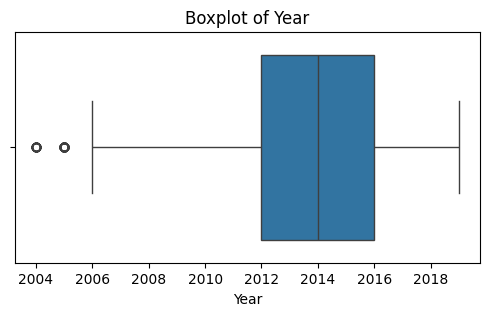

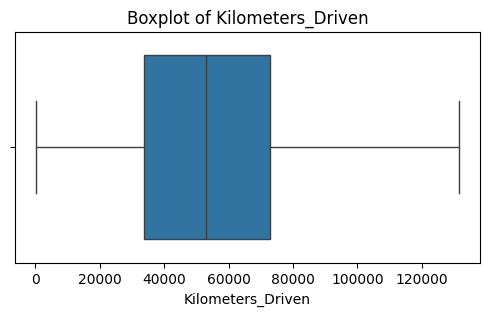

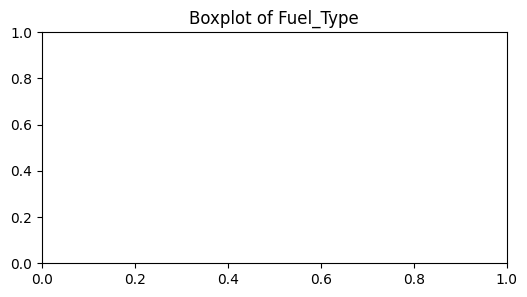

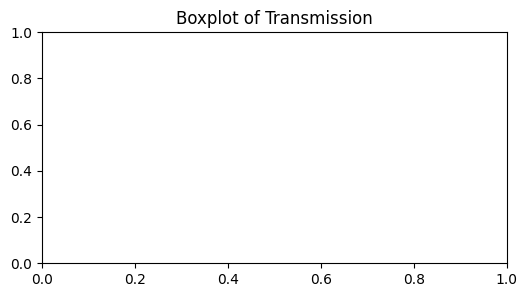

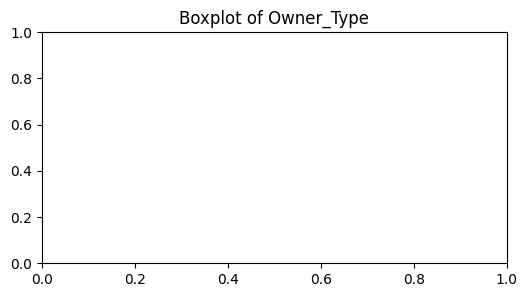

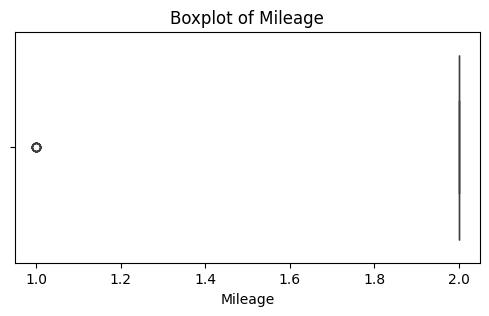

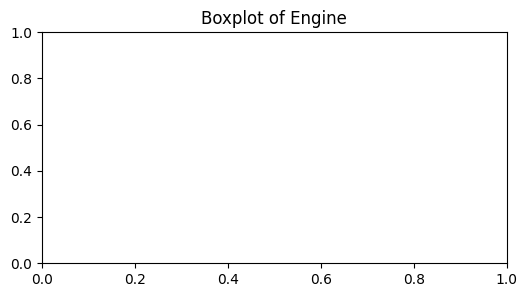

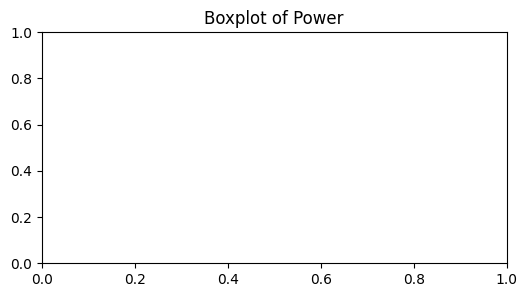

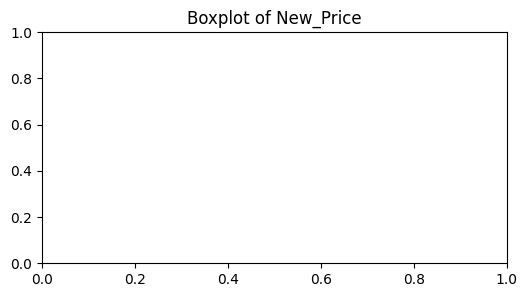

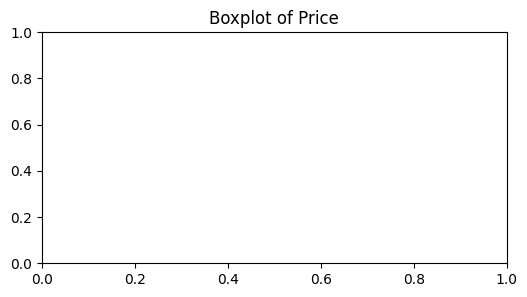

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col].dropna())   # ✅ drop NaN values
    plt.title(f"Boxplot of {col}")
    plt.show()


In [13]:
# Convert all numeric columns safely
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

# If some columns are still object type but should be numeric, convert them
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


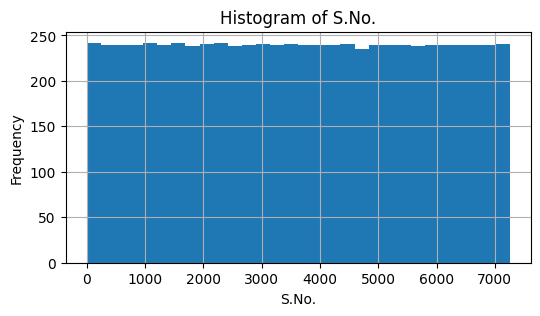

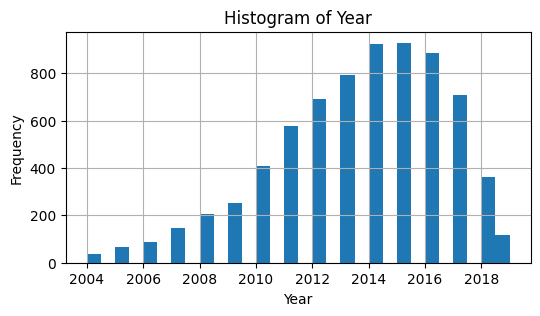

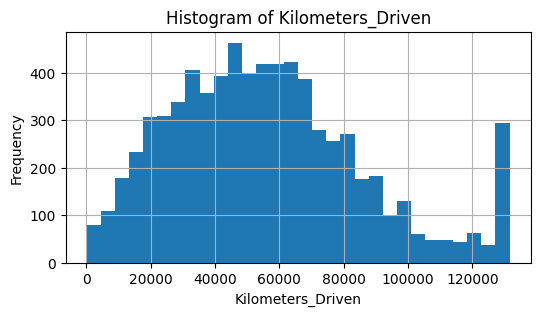

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [17]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\nColumn: {col}")
    print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    print(f"Number of outliers: {outliers.shape[0]}")



Column: S.No.
Lower bound: -3637.5, Upper bound: 10882.5
Number of outliers: 0

Column: Year
Lower bound: 2006.0, Upper bound: 2022.0
Number of outliers: 103

Column: Kilometers_Driven
Lower bound: -24831.75, Upper bound: 131510.25
Number of outliers: 0


In [16]:
df['Year_Category'] = df['Year'].apply(lambda x: 'Old' if x < 2006 else 'Modern')

df.loc[df['Kilometers_Driven'] > 131500, 'Kilometers_Driven'] = 131500
df['Seats'] = df['Seats'].apply(lambda x: x if x == 5 else 'Other')

